In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

In [2]:
# train.csv einlesen
train_file_path = "train.csv"
f1_data = pd.read_csv(train_file_path)

In [3]:
# y zuteilen --> PitNextLap
y = f1_data.PitNextLap

In [4]:
#Rausfinden welche verschiedene reifen es gibt
print("Reifen im Trainingsset:", f1_data["Compound"].unique())

Reifen im Trainingsset: <StringArray>
['HARD', 'MEDIUM', 'INTERMEDIATE', 'SOFT', 'WET']
Length: 5, dtype: str


In [5]:
#Text-Spalten in eindeutige Zahlen-Codes umwandeln
f1_data["Race_Code"] = f1_data["Race"].astype("category").cat.codes
f1_data["Driver_Code"] = f1_data["Driver"].astype("category").cat.codes

#Mapping definieren und die Spalte berechnen
reifen_mapping = {
    "HARD": 0,
    "MEDIUM": 1,
    "SOFT": 2,
    "INTERMEDIATE": 3,
    "WET": 4
}
f1_data["Compound_Code"] = f1_data["Compound"].map(reifen_mapping).fillna(-1)

#Neues Feature berechnen mit höchsten Mi-Scores
f1_data["Stint_Progress"] = f1_data["RaceProgress"] * f1_data["Stint"]

In [6]:
# feature erstellen und X zuteilen
features = [
    "Stint",
    "TyreLife",
    "Position",
    "Cumulative_Degradation",
    "RaceProgress",
    "Position_Change",
    "LapTime_Delta",
    "Stint_Progress",  #neuer Fortschritts-Faktor ermittelt durch MI-Score
    "Compound_Code", #neues Feature durch mapping
    "Race_Code",    #Die Strecke
    "Driver_Code"   #Der Fahrer
]

X = f1_data[features]

In [7]:
# in Validierung und Trainigsdaten aufteilen
train_X, val_X, train_y, val_y = train_test_split(X, y, random_state=1)

In [8]:
# Modell definieren und trainieren (deine Einstellungen aus Screenshot [12])
rf_model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=1)
rf_model.fit(train_X, train_y)

print("Modell ist bereit für die Analyse!")

Modell ist bereit für die Analyse!


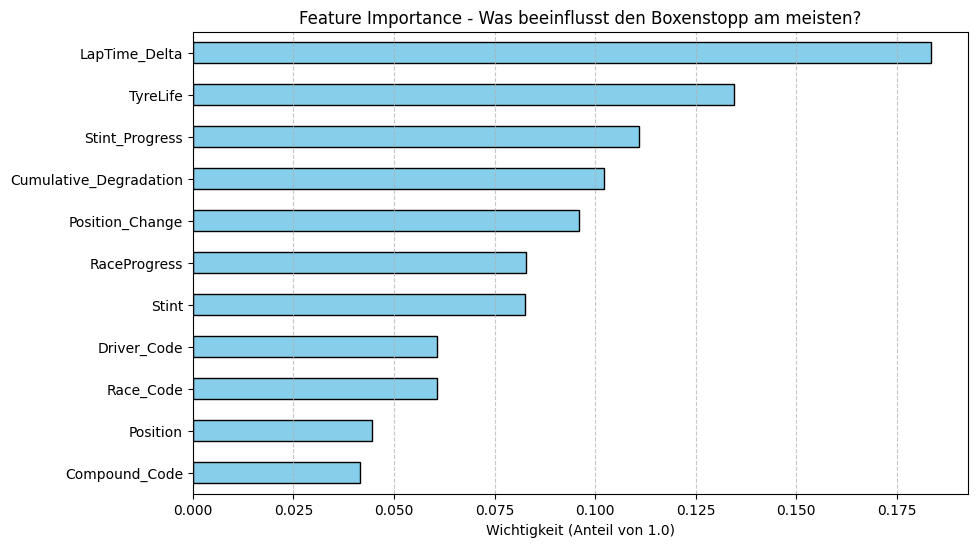

In [10]:
#Daten für den Plot vorbereiten
importances = pd.Series(rf_model.feature_importances_, index=features)
importances = importances.sort_values(ascending=True)

#Grafik zeichnen
plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='skyblue', edgecolor='black')
plt.title('Feature Importance - Was beeinflusst den Boxenstopp am meisten?')
plt.xlabel('Wichtigkeit (Anteil von 1.0)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()